In [2]:
# Starter code

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
len(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
block_size = 3 # context length

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     
Xdev, Ydev = build_dataset(words[n1:n2])   
Xte,  Yte  = build_dataset(words[n2:])     

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3)/((n_embd*block_size)**0.5) # gain/sqrt(fan_in) instead of a random 0.2
# b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 
b2 = torch.randn(vocab_size, generator=g) * 0 # so that b2 is 0 at initialisation
bngain=torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running=torch.zeros((1,n_hidden))
bnstd_running= torch.ones((1,n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


0.3042903097250923

tensor(0.0023) tensor(1.0044)
tensor(0.0004) tensor(1.0121)


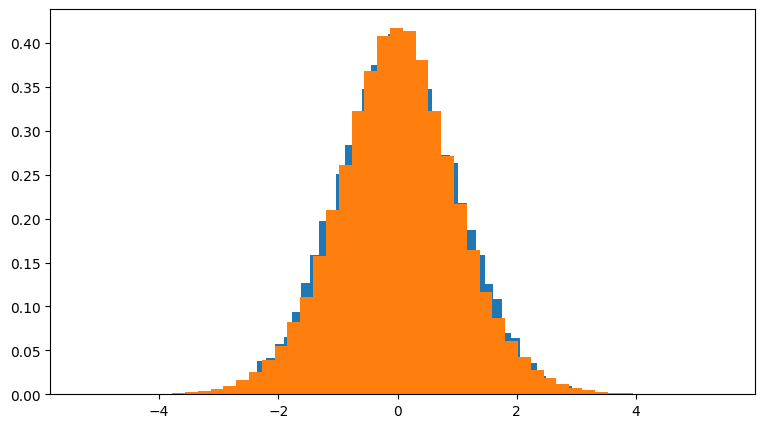

In [ ]:
x=torch.randn(1000,10)
w=torch.randn(10,200) /10**0.5 # preserved the std dev to 1, 10 is the input of w (fan_in)
y = x @ w
# this kind of initialisation is also in pytorch (kaining normal)
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(122)
plt.hist(x.view(-1).tolist(),50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);
# std dev y is 3 whereas of x it is 1 so we need a multiplying factor

In [ ]:
max_steps=200000
batch_size=32
lossi=[]

for i in range (max_steps):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,) ) 
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X ,Y
    # forward pass
    emb = C[Xb] 
    embcat=emb.view(emb.shape[0], -1)
    hpreact= embcat @ W1 # +b1 # we are adding b1 here but then subtracting in the mean hpreact which cancels out this addition so its wasteful 
    # conventional to take a linear layer and append a batch normalisation right after it to control the scale of these activations 
    # pre activation states should be roughly gaussian and we can just normalise them to be gaussian and its perfectly differenciable(batch normalisation paper)
    # h pre activation is too far off from 0 creating a tanh that is saturated on the two ends
    # if hpreact is too small tanh is inactive if they are too large tanh is saturated
    bnmeani=hpreact.mean(0,keepdim=True)
    bnstdi= hpreact.std(0,keepdim=True)
    hpreact= bngain*(hpreact-bnmeani)/bnstdi +bnbias # we add an epsilon generally 1 * e^-5 to avoid division by zero , and bnbias also replaces b1 that was redundant above
    # hpreact= bngain*(hpreact-hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) +bnbias
    # scale and shift multiplied by bngain and added bnbias(as suggested in the paper)
    # we want these to be gaussian but only at initialisation
    with torch.no_grad():
        bnmean_running= 0.999*bnmean_running + 0.001 * bnmeani
        bnstd_running= 0.999*bnstd_running + 0.001 * bnstdi 
    # batch normalisation is used to control the statistics of activations in neural net, its conventional to sprinkle it in the net usually placed after layers with multiplications like the linear layer above or convolutional layer
    # bn internally has parameters gain and bias which are trained using backpropagation, also has two buffers running mean and std not trained using backpropagation but just update

    h=torch.tanh(hpreact) # jitters for h and logits which is a side effect but works as a regularisation
    # gradient of tanh is defined as (1-t**2)*out.grad but if t = 1 or -1 it makes the whole term zero effectively removing the influence of out.grad and making self.grad =0
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Yb)
    
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.1 if i <100000 else 0.01
    for p in parameters:
        p.data+= -lr*p.grad 
    
    # track stats:
    if i % 1000==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): 4f}')
   
    lossi.append(loss.log10().item())
    # break
print(loss.item()) 
# search resnet , linear layers, batch norm 1d in pytorch
#class torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
#class torch.nn.BatchNorm1d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None, *, bias=True)
# note the use of all these parameters

      0/ 200000:  3.313053
   1000/ 200000:  2.237859
   2000/ 200000:  1.955604
   3000/ 200000:  1.988765
   4000/ 200000:  2.027165
   5000/ 200000:  2.626991
   6000/ 200000:  2.543490
   7000/ 200000:  2.228832
   8000/ 200000:  2.017112
   9000/ 200000:  2.366860
  10000/ 200000:  2.232453
  11000/ 200000:  2.290442
  12000/ 200000:  2.368275
  13000/ 200000:  2.078354
  14000/ 200000:  1.828697
  15000/ 200000:  1.878953
  16000/ 200000:  2.549182
  17000/ 200000:  2.343112
  18000/ 200000:  2.584044
  19000/ 200000:  2.300876
  20000/ 200000:  2.387549
  21000/ 200000:  2.073867
  22000/ 200000:  2.117922
  23000/ 200000:  2.526064
  24000/ 200000:  2.358074
  25000/ 200000:  2.572702
  26000/ 200000:  2.414462
  27000/ 200000:  2.436878
  28000/ 200000:  2.719504
  29000/ 200000:  2.177588
  30000/ 200000:  2.186248
  31000/ 200000:  2.087452
  32000/ 200000:  2.177533
  33000/ 200000:  2.133122
  34000/ 200000:  2.109569
  35000/ 200000:  2.466337
  36000/ 200000:  2.179320
 

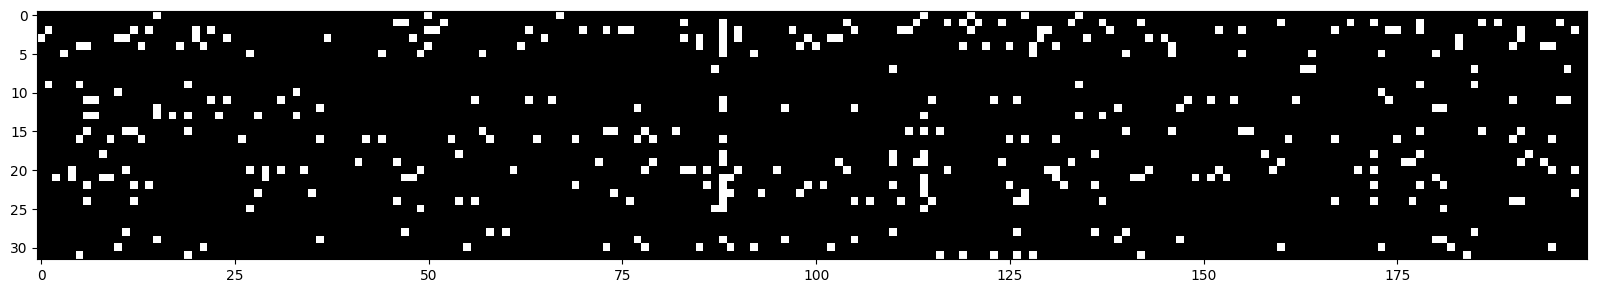

In [66]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs()> 0.99, cmap='gray',interpolation='nearest') #white if true
# no columns of complete white which means there are no dead neurons
# the problem with too many neurons in that range is that they lie in the inactive part of tanh function this will happen in any function with flat parts relu or sigmoid

In [67]:
h.view(-1).shape

torch.Size([6400])

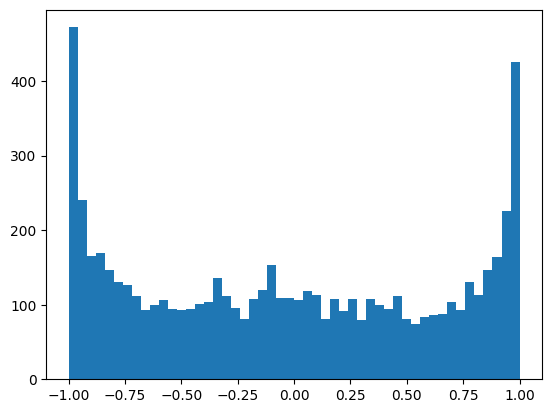

In [68]:
plt.hist(h.view(-1).tolist(),50); # ; for just the graph without excess information
# after multiplying W1 with 0.2 and b1 with 0.01 we have much better graph

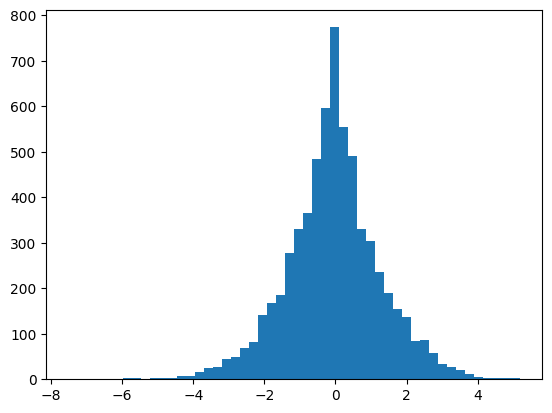

In [69]:
plt.hist(hpreact.view(-1).tolist(),50);

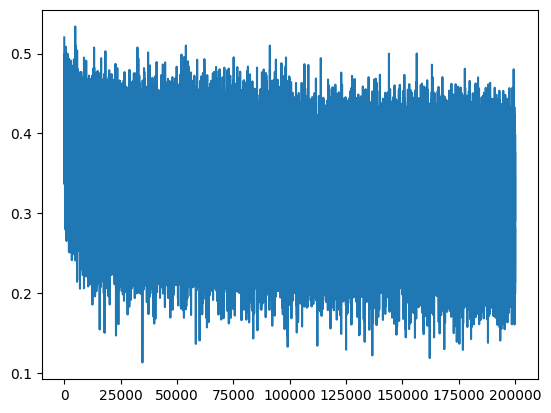

In [70]:
plt.plot(lossi)
# not hockey stick shape anymore because there the optimisation first compresses the logits and then rearrage it. We took away the first part
# this is true for all neural nets

In [16]:
# we expect the initial loss to be the negative log probability where all the characters are equally likely
-torch.tensor(1/27.0).log() # this is expected initial loss

tensor(3.2958)

In [ ]:
# # clean version
# # same optimization as last time
# max_steps = 200000
# batch_size = 32
# lossi = []

# for i in range(max_steps):
  
#   # minibatch construct
#   ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
#   Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
#   # forward pass
#   emb = C[Xb] # embed the characters into vectors
#   embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
#   # Linear layer
#   hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
#   # BatchNorm layer
#   # -------------------------------------------------------------
#   bnmeani = hpreact.mean(0, keepdim=True)
#   bnstdi = hpreact.std(0, keepdim=True)
#   hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
#   with torch.no_grad():
#     bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
#     bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
#   # -------------------------------------------------------------
#   # Non-linearity
#   h = torch.tanh(hpreact) # hidden layer
#   logits = h @ W2 + b2 # output layer
#   loss = F.cross_entropy(logits, Yb) # loss function
  
#   # backward pass
#   for p in parameters:
#     p.grad = None
#   loss.backward()
  
#   # update
#   lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
#   for p in parameters:
#     p.data += -lr * p.grad

#   # track stats
#   if i % 10000 == 0: # print every once in a while
#     print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
#   lossi.append(loss.log10().item())

In [71]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1  + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
  # just to remove the hassle of getting mean and std separately we get them earlier as running mean and std

In [ ]:
bnmean

tensor([[-2.9562e+00,  7.9860e-02, -1.3980e+00,  1.1414e+00,  9.3114e-01,
          1.0331e+00,  3.0702e+00, -1.3537e+00,  6.8213e-01,  1.2795e+00,
         -1.6209e+00, -2.3254e+00,  9.1314e-02, -5.4648e-02,  3.4606e-01,
         -4.6685e-01,  4.5272e-01, -2.3957e+00, -4.8004e-01,  1.4930e+00,
         -8.3922e-01,  2.5876e-01,  1.2250e-01, -7.6717e-02,  1.2242e+00,
          4.6884e-01,  1.4433e+00,  5.9559e-01,  4.4927e-01,  1.7104e+00,
          5.0505e-02, -9.2694e-01,  4.2240e-01,  6.0632e-01,  4.7826e-01,
         -1.2968e+00,  5.2591e-01,  6.6818e-02,  5.9044e-01,  5.8166e-01,
         -3.3923e-01, -1.6071e+00, -1.0460e+00, -7.8060e-02,  8.9086e-01,
          4.0490e-01,  1.0202e+00, -3.5102e-01,  2.4001e+00,  1.6613e+00,
          1.6448e+00,  8.3795e-02,  2.0306e+00,  4.5448e-01,  7.9807e-01,
         -2.9894e+00, -6.2486e-01,  2.3228e-01,  1.5168e+00, -1.1582e+00,
         -4.5566e-01,  1.2830e+00,  5.4498e-02,  6.2164e-01,  2.1147e+00,
          1.3403e+00,  1.1177e-01,  1.

In [ ]:
bnmean_running # almost similar

tensor([[-2.9562e+00,  7.9860e-02, -1.3980e+00,  1.1414e+00,  9.3114e-01,
          1.0331e+00,  3.0702e+00, -1.3537e+00,  6.8213e-01,  1.2795e+00,
         -1.6209e+00, -2.3254e+00,  9.1314e-02, -5.4648e-02,  3.4606e-01,
         -4.6685e-01,  4.5272e-01, -2.3957e+00, -4.8004e-01,  1.4930e+00,
         -8.3922e-01,  2.5876e-01,  1.2250e-01, -7.6717e-02,  1.2242e+00,
          4.6884e-01,  1.4433e+00,  5.9559e-01,  4.4927e-01,  1.7104e+00,
          5.0505e-02, -9.2694e-01,  4.2240e-01,  6.0632e-01,  4.7826e-01,
         -1.2968e+00,  5.2591e-01,  6.6818e-02,  5.9044e-01,  5.8166e-01,
         -3.3923e-01, -1.6071e+00, -1.0460e+00, -7.8060e-02,  8.9086e-01,
          4.0490e-01,  1.0202e+00, -3.5102e-01,  2.4001e+00,  1.6613e+00,
          1.6448e+00,  8.3795e-02,  2.0306e+00,  4.5448e-01,  7.9807e-01,
         -2.9894e+00, -6.2486e-01,  2.3228e-01,  1.5168e+00, -1.1582e+00,
         -4.5566e-01,  1.2830e+00,  5.4498e-02,  6.2164e-01,  2.1147e+00,
          1.3403e+00,  1.1177e-01,  1.

In [76]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact= embcat @ W1 #+b1 
  # hpreact= bngain*(hpreact-hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) +bnbias
  hpreact= bngain*(hpreact-bnmean_running)/bnstd_running + bnbias

  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
# better loss after the initialising properly because we spend more iterations making the neural net better than compression

train 2.0668890476226807
val 2.110020637512207


In [36]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahela.
jharli.
jari.
reigh.
skansh.
emmahnel.
deliya.
jareei.
nellara.
chaily.
kaleigh.
ham.
joce.
quinthorlen.
alian.
quinte.
madiarynn.
jaxeenitraylen.
edi.
abette.
